C:\Users\Redie\AppData\Local\Temp\ipykernel_28568\1000675726.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], index_col='Date')


Missing values count: 0


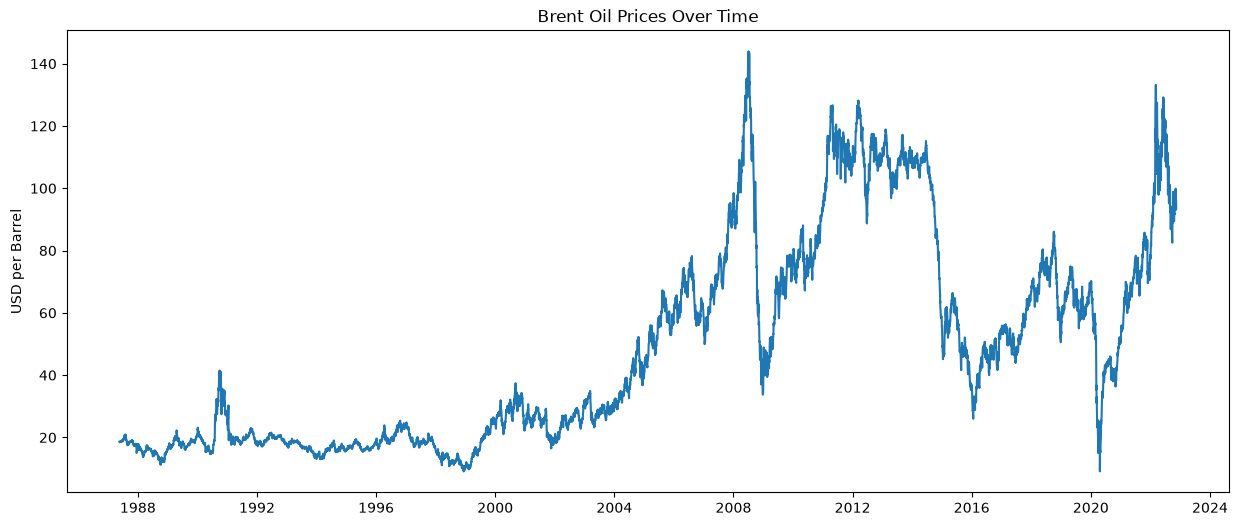

ADF Statistic: -1.993856011392466
p-value: 0.2892735048934034
Critical Values: 1%: -3.4310783342658615
Critical Values: 5%: -2.861861876398633
Critical Values: 10%: -2.566941329781918
Result: Series is non-stationary (Fail to reject H0)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. Load Data
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], index_col='Date')
df = df.sort_index()
df['Price'] = df['Price'].ffill()

# 4. Check for any remaining NaNs
print(f"Missing values count: {df['Price'].isna().sum()}")

# 2. Visualize Trend
plt.figure(figsize=(15, 6))
plt.plot(df['Price'])
plt.title('Brent Oil Prices Over Time')
plt.ylabel('USD per Barrel')
plt.show()

# 3. Stationarity Testing (ADF)
result = adfuller(df['Price'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print(f'Critical Values: {key}: {value}')

if result[1] < 0.05:
    print("Result: Series is stationary (Reject H0)")
else:
    print("Result: Series is non-stationary (Fail to reject H0)")